# Sneha Singh
## DATA 266 — Homework 4
Mini-GPT from scratch (char-level, decoder-only)


In [1]:
# libraries — no nn.Transformer, nn.MultiheadAttention, or HuggingFace
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

SEED = 670
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path(".").resolve()
DATA_PATH = ROOT / "data" / "shakespeare.txt"

print("SEED:", SEED)
print("device:", DEVICE)
print("torch:", torch.__version__)
print("data:", DATA_PATH, "exists=", DATA_PATH.exists())


SEED: 670
device: cpu
torch: 2.13.0
data: /Users/snehasingh/Desktop/Gen-Ai/HW-4/data/shakespeare.txt exists= True


## Part 1 — Data preparation

### 1.1 Character-level tokenization

Read `shakespeare.txt`, build `char_to_idx` / `idx_to_char`, print vocab size.


In [2]:
# load course shakespeare file (character level)
text = DATA_PATH.read_text(encoding="utf-8")
print("chars in file:", len(text))
print("first 200 chars:\n", text[:200])

chars = sorted(set(text))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size = len(chars)

print("vocab size:", vocab_size)
print("vocab:", "".join(chars))


chars in file: 1738
first 200 chars:
 ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her mai
vocab size: 49
vocab: 
 !,.:;?ABCDEHIJLMNORSTUWabcdefghiklmnoprstuvwyz’


### 1.2 Sliding window dataset

Sequence length = **128**.

- Input: `[t … t+127]`
- Target: `[t+1 … t+128]` (next character)

Two decoded examples below.


In [3]:
SEQ_LEN = 128

data = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)
print("token tensor length:", len(data))

def decode(ids):
    if torch.is_tensor(ids):
        ids = ids.tolist()
    return "".join(idx_to_char[i] for i in ids)

# two example windows
for start in (0, 500):
    inp = data[start : start + SEQ_LEN]
    tgt = data[start + 1 : start + SEQ_LEN + 1]
    print("\n===== start =", start, "=====")
    print("INPUT :", repr(decode(inp)))
    print("TARGET:", repr(decode(tgt)))
    print("note: target = input shifted by 1")


token tensor length: 1738

===== start = 0 =====
INPUT : 'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the '
TARGET: 'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'
note: target = input shifted by 1

===== start = 500 =====
INPUT : ' am too bold, ’tis not to me she speaks:\nTwo of the fairest stars in all the heaven,\nHaving some business, do entreat her eyes\nT'
TARGET: 'am too bold, ’tis not to me she speaks:\nTwo of the fairest stars in all the heaven,\nHaving some business, do entreat her eyes\nTo'
note: target = input shifted by 1


In [4]:
# sliding windows for training (stride=32)
class CharWindowDataset(Dataset):
    def __init__(self, data, seq_len=128, stride=32):
        self.data = data
        self.seq_len = seq_len
        self.starts = list(range(0, len(data) - seq_len, stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        s = self.starts[i]
        chunk = self.data[s : s + self.seq_len + 1]
        x = chunk[:-1]  # [t .. t+127]
        y = chunk[1:]   # [t+1 .. t+128]
        return x, y

dataset = CharWindowDataset(data, SEQ_LEN, stride=32)
print("number of windows:", len(dataset))
x0, y0 = dataset[0]
print("one batch item shapes:", x0.shape, y0.shape)


number of windows: 51
one batch item shapes: torch.Size([128]) torch.Size([128])


## Part 2 — GPT architecture

Manual multi-head causal attention (4 heads), then decoder blocks with residual + LayerNorm + FFN (`Linear → GELU → Linear`). Model: token emb + learnable pos emb + 2 blocks + vocab head.


In [5]:
# multi-head causal attention (manual QKV)

class MultiHeadCausalAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        # True = future positions blocked
        mask = torch.triu(torch.ones(block_size, block_size), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # causal mask
        att = att.masked_fill(self.causal_mask[:T, :T], float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


# decoder block
class DecoderBlock(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadCausalAttention(n_embd, n_head, block_size)
        self.ln2 = nn.LayerNorm(n_embd)
        # FFN
        self.ff = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


# mini GPT
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, n_embd=128, n_head=4, n_layer=2, block_size=128):
        super().__init__()
        self.block_size = block_size
        self.n_embd = n_embd
        self.n_head = n_head
        self.n_layer = n_layer
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList(
            [DecoderBlock(n_embd, n_head, block_size) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.head(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


# 4 heads, 2 layers
N_EMBD = 128
N_HEAD = 4
N_LAYER = 2
model = MiniGPT(vocab_size, N_EMBD, N_HEAD, N_LAYER, SEQ_LEN).to(DEVICE)

print("total parameters:", model.count_params())
print("hidden dim (n_embd):", model.n_embd)
print("number of heads:", model.n_head)
print("number of layers:", model.n_layer)
print("block / seq len:", model.block_size)


total parameters: 425728
hidden dim (n_embd): 128
number of heads: 4
number of layers: 2
block / seq len: 128


## Part 3 — Training

Adam, lr `3e-4`, batch size `64`, **8** epochs. Each epoch uses 300 random minibatches, then I plot train loss vs epoch.


In [6]:
# training hyperparameters
BATCH = 64
EPOCHS = 8
STEPS_PER_EPOCH = 300
LR = 3e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
epoch_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    running = []
    for step in range(STEPS_PER_EPOCH):
        ix = torch.randint(0, len(dataset), (BATCH,))
        xs, ys = zip(*[dataset[i] for i in ix.tolist()])
        xb = torch.stack(xs).to(DEVICE)
        yb = torch.stack(ys).to(DEVICE)

        logits = model(xb)
        loss = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        running.append(loss.item())

    mean_loss = float(np.mean(running))
    epoch_losses.append(mean_loss)
    print(f"epoch {epoch}/{EPOCHS}  train_loss={mean_loss:.4f}")

print("final losses:", epoch_losses)


epoch 1/8  train_loss=1.8486
epoch 2/8  train_loss=0.1176
epoch 3/8  train_loss=0.0202
epoch 4/8  train_loss=0.0148
epoch 5/8  train_loss=0.0131
epoch 6/8  train_loss=0.0124
epoch 7/8  train_loss=0.0120
epoch 8/8  train_loss=0.0116
final losses: [1.8486466011404992, 0.11761540262649457, 0.020167393603672583, 0.01475629849669834, 0.013125051762908697, 0.012393086959297459, 0.011955332101012269, 0.011615568893030287]


epoch 2/8  train_loss=0.1176


epoch 3/8  train_loss=0.0202


epoch 4/8  train_loss=0.0148


epoch 5/8  train_loss=0.0131


epoch 6/8  train_loss=0.0124


epoch 7/8  train_loss=0.0120


epoch 8/8  train_loss=0.0116
final losses: [1.8486466011404992, 0.11761540262649457, 0.020167393603672583, 0.01475629849669834, 0.013125051762908697, 0.012393086959297459, 0.011955332101012269, 0.011615568893030287]


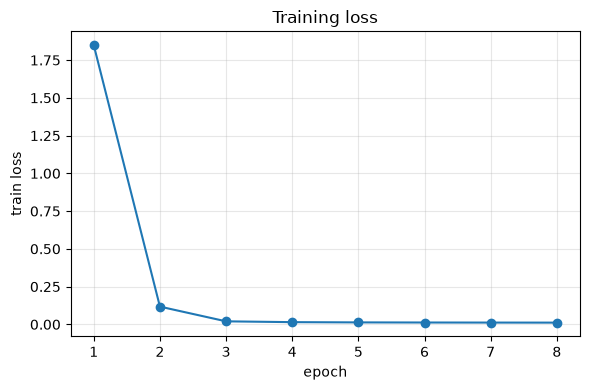

In [7]:
# loss curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker="o")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/train_loss.png", dpi=140)
plt.show()


## Part 4 — Sampling

Prompt: **`ROMEO:`**

1. Greedy (argmax)
2. Temperature — `0.2`, `0.7`, `1.2`
3. Top-k — `k=5` and `k=50`


In [8]:
# sampling helpers

@torch.no_grad()
def generate(model, start_ids, max_new_tokens, *, temperature=1.0, top_k=None, greedy=False):
    model.eval()
    idx = start_ids.clone()
    for _ in range(max_new_tokens):
        ctx = idx[:, -model.block_size :]
        logits = model(ctx)[:, -1, :]

        if greedy:
            next_id = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits = logits / max(temperature, 1e-8)
            if top_k is not None:
                values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                cutoff = values[:, [-1]]
                logits = logits.masked_fill(logits < cutoff, float("-inf"))
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        idx = torch.cat([idx, next_id], dim=1)
    return idx


def encode(s):
    return torch.tensor([[char_to_idx[c] for c in s]], dtype=torch.long, device=DEVICE)

PROMPT = "ROMEO:"
prompt_ids = encode(PROMPT)
MAX_NEW = 200
print("prompt:", PROMPT)


prompt: ROMEO:


In [9]:
# 4.1 greedy decoding
torch.manual_seed(SEED)
out = generate(model, prompt_ids, MAX_NEW, greedy=True)
text_greedy = decode(out[0])
print("=== GREEDY ===")
print(text_greedy)


=== GREEDY ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e shilo me m,
So we  e? erthe?
 sano 
So  bak  mee me tot mo  oto taveosandear


In [10]:
# 4.2 temperature sampling — three temperatures
temps = [0.2, 0.7, 1.2]
text_temp = {}
for T in temps:
    torch.manual_seed(SEED + int(T * 10))
    out = generate(model, prompt_ids, MAX_NEW, temperature=T)
    text_temp[T] = decode(out[0])
    print(f"\n=== TEMPERATURE T={T} ===")
    print(text_temp[T])



=== TEMPERATURE T=0.2 ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e shilo me m,
So we  e? 
  eso O:
So ealetotot meo me alo otheostashtotalo the

=== TEMPERATURE T=0.7 ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e shilo me m,
So we  e? e?
 eULI   me o mome.
So eceteousalrtanthale  erto eav

=== TEMPERATURE T=1.2 ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e sh ; o  e ; o eallotk 
 wisaltou me eck SaTesteo  e alo ; erto be !
So  eck 



=== TEMPERATURE T=1.2 ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e sh ; o  e ; o eallotk 
 wisaltou me eck SaTesteo  e alo ; erto be !
So  eck 


In [11]:
# 4.3 top-k sampling — two values of k
ks = [5, 50]
text_topk = {}
for k in ks:
    torch.manual_seed(SEED + k)
    out = generate(model, prompt_ids, MAX_NEW, temperature=1.0, top_k=k)
    text_topk[k] = decode(out[0])
    print(f"\n=== TOP-K k={k} ===")
    print(text_topk[k])



=== TOP-K k=5 ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e shilome e  to ick  e?
So e alertande she.
So  o meteaveweh  eck talo ;

Sart

=== TOP-K k=50 ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e she  o sh ?
 aste  e
 
 ptilto meet’do  beot meo pheaveck erto  thasak  eck 



=== TOP-K k=50 ===
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e she  o sh ?
 aste  e
 
 ptilto meet’do  beot meo pheaveck erto  thasak  eck 


## Part 5 — Short analysis

- **Greedy:** always pick the top character. Same every time. On my run it reprints the balcony opening from the training file, then drifts a little.
- **Temperature:** divide logits by T. `0.2` looks almost like greedy. `0.7` gets messier. `1.2` is the noisiest.
- **Top-k:** only sample from the k best chars. `k=5` stays tighter; `k=50` wanders more.

**Most coherent: greedy decoding.** It always takes the highest-probability next character, so the text stays more stable / predictable. Temperature `0.2` behaved almost the same because the distribution is still very peaked, but greedy is the clearest “most coherent” method.

**Most diverse: temperature sampling with T = 1.2.** The flatter distribution lets rarer characters through. Top-k `50` is also fairly mixed, but `1.2` was the wildest on my prints.

The course file is short, so every method still starts by copying the memorized `ROMEO:` lines. Differences show up more in the tail.
